In [67]:
import numpy as np
import time as time_lib
import random as rd
import copy
import psutil
import gc
import pickle
from qiskit.quantum_info import SparsePauliOp
n_qubit = 1
dim     = 2**n_qubit
nld     = 11
lds     = np.linspace(0,1,num=nld)

In [68]:
def memory_usage(message: str = 'debug'):
    # this memory_usage function is imported from https://jybaek.tistory.com/895
    # current process RAM usage
    p = psutil.Process()
    rss = p.memory_info().rss / 2 ** 30 # Bytes to GiB
    print(f"[{message}] memory usage: {rss: 10.5f} GiB")

In [69]:
t_x          = 0.5
t_zs         = []
hamiltonians = []
alpha        = 0
for ld in lds:
    t_z = -1 + 2.0 * ld
    h = SparsePauliOp.from_list([('X',t_x),('Z',t_z)])
    t_zs.append(t_z)
    hamiltonians.append(h)
    print(hamiltonians[alpha])
    alpha += 1


SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -1. +0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -0.8+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -0.6+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -0.4+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -0.2+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 0. +0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 0.2+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 0.4+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 0.6+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 0.8+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 1. +0.j])


In [70]:
hamiltonian_diffs = []
for ild in range(nld-1):
    hamiltonian_diffs.append((hamiltonians[ild+1]-hamiltonians[ild]).simplify())
    print(hamiltonian_diffs[ild])

SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])
SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])
SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])
SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])
SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])
SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])
SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])
SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])
SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])
SparsePauliOp(['Z'],
              coeffs=[0.2+0.j])


In [71]:
hamiltonian_diffs_list = []
for ild in range(nld-1):
    hamiltonian_diffs_list.append(hamiltonian_diffs[ild].to_list())
    print(hamiltonian_diffs_list[ild])

[('Z', (0.19999999999999996+0j))]
[('Z', (0.20000000000000007+0j))]
[('Z', (0.20000000000000007+0j))]
[('Z', (0.19999999999999996+0j))]
[('Z', (0.19999999999999996+0j))]
[('Z', (0.20000000000000018+0j))]
[('Z', (0.19999999999999996+0j))]
[('Z', (0.19999999999999996+0j))]
[('Z', (0.19999999999999996+0j))]
[('Z', (0.19999999999999996+0j))]


In [72]:
n_hamiltonians = len(hamiltonians)

In [73]:
# exact eigenvalues
eigen_energies_exact  = np.zeros((nld,dim),dtype=float)
eigen_vectors_exact   = np.zeros((nld,dim,dim),dtype=complex)
for ild in range(nld):
    eigen_e, eigen_v = np.linalg.eigh(hamiltonians[ild].to_matrix())
    indx = np.argsort(eigen_e.real)
    for i in range(dim):
        eigen_energies_exact[ild,i]   = eigen_e[indx[i]].real
        eigen_vectors_exact[ild,:,i] = eigen_v[:,indx[i]]


In [74]:
x_op = SparsePauliOp.from_list([('X',1.0)])
y_op = SparsePauliOp.from_list([('Y',1.0)])
z_op = SparsePauliOp.from_list([('Z',1.0)])
x_mat = x_op.to_matrix()
y_mat = y_op.to_matrix()
z_mat = z_op.to_matrix()

In [75]:
def ComputeUnitaryParams(U):
    theta = 2.0 * np.arccos(np.abs(U[0,0]))
    if (theta<1E-6):
        theta = 2.0*np.arcsin(np.abs(U[0,1]))
    gamma = np.angle(U[0,0])
    if (theta<1E-10):
        phi   = np.angle(U[1,1]/U[0,0])
        lam   = 0
    else:
        phi   = np.angle(U[1,0]/np.sin(theta/2)) - gamma
        lam   = np.angle(-U[0,1]/np.sin(theta/2)) - gamma
    return [theta, phi, lam, gamma]

def ExactTimeEvolution (alpha, time):
    Vl = copy.deepcopy(eigen_vectors_exact[alpha,:,:])
    evol = np.zeros((dim,dim),dtype=complex)
    exp_d = np.diag(np.exp(-1j*eigen_energies_exact[alpha,:]*time))
    evol = Vl@exp_d@Vl.conj().T
    return evol

def TrotterTimeEvolution (alpha, Nt, time):
    dtime  = time/Nt
    dtx = dtime * t_x
    dtz = dtime * t_zs[alpha]
    evol = np.identity(dim)
    for it in range(Nt):
        evol_X = np.cos(dtx)*np.identity(dim) - 1j*np.sin(dtx) * x_mat
        evol_Z = np.cos(dtz)*np.identity(dim) - 1j*np.sin(dtz) * z_mat
        evol = evol_Z@evol
        evol = evol_X@evol
    return evol

In [76]:
# exact results
norms_exact  = np.ones((nld,dim),dtype=float)
for i in range(dim):
    phi = eigen_vectors_exact[0,:,i]
    for alpha in range(1,nld):
        proj_matrix = np.outer(eigen_vectors_exact[alpha,:,i],eigen_vectors_exact[alpha,:,i].conj())
        phi = proj_matrix@phi
        norms_exact[alpha,i] = phi.conj()@phi

x_exps_exact = np.zeros((nld,dim),dtype=float)
y_exps_exact = np.zeros((nld,dim),dtype=float)
z_exps_exact = np.zeros((nld,dim),dtype=float)
for ild in range(nld):
    for i in range(dim):
        x_exps_exact[ild,i] = eigen_vectors_exact[ild,:,i].conj().transpose()@x_mat@eigen_vectors_exact[ild,:,i]
        y_exps_exact[ild,i] = eigen_vectors_exact[ild,:,i].conj().transpose()@y_mat@eigen_vectors_exact[ild,:,i]
        z_exps_exact[ild,i] = eigen_vectors_exact[ild,:,i].conj().transpose()@z_mat@eigen_vectors_exact[ild,:,i]

/tmp/ipykernel_29113/1490341378.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  norms_exact[alpha,i] = phi.conj()@phi
/tmp/ipykernel_29113/1490341378.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  x_exps_exact[ild,i] = eigen_vectors_exact[ild,:,i].conj().transpose()@x_mat@eigen_vectors_exact[ild,:,i]
/tmp/ipykernel_29113/1490341378.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  y_exps_exact[ild,i] = eigen_vectors_exact[ild,:,i].conj().transpose()@y_mat@eigen_vectors_exact[ild,:,i]
/tmp/ipykernel_29113/1490341378.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  z_exps_exact[ild,i] = eigen_vectors_exact[ild,:,i].conj().transpose()@z_mat@eigen_vectors_exact[ild,:,i]


In [77]:
nmc = int(400)
n_shot = 4000

In [78]:
beta = 5

In [79]:
n_obs = 3
with open('/home/mchan/Doc/articles/QZMC/Figures/mdf-data/supp-data/n_trotter/MDH.time.binary','rb') as file_:
    [O_timelists] = pickle.load(file_)
#O_timelists         = [[[[] for _ in range(nmc)] for _ in range(n_obs)] for _ in range(n_hamiltonians)]
#for alpha in range(1,n_hamiltonians):
#    for i_obs in range(n_obs):
#        for imc in range(nmc):
#            times = np.random.normal(0.0, beta, size=2*(alpha))
#            O_timelists[alpha][i_obs][imc] = times
#

In [80]:
#with open('MDH.time.binary','wb') as file_:
#    pickle.dump([O_timelists],file_)

In [81]:
N_T_list = [40, 30, 20, 15, 10, 9, 8, 7, 6]
#N_T_list = [6]
n_N_T = len(N_T_list)
print(n_N_T)
norms_trotter = np.ones((n_N_T, n_hamiltonians), dtype=float)
eigen_energies_trotter = np.zeros((n_N_T, n_hamiltonians), dtype=float)
eigen_energies_trotter[:,0] = eigen_energies_exact[0,0]
Z_trotter                   = np.zeros((n_N_T),dtype=float)


9


In [82]:
# exact version
eigen_energies_test = np.zeros((n_hamiltonians), dtype=float)
eigen_energies_test[0] = eigen_energies_exact[0,0]
norms_test = np.zeros((n_hamiltonians), dtype=float)
eps = eigen_vectors_exact[0,:,0].conj().T@hamiltonians[1].to_matrix()@eigen_vectors_exact[0,:,0]
eps = eps.real
for alpha in range(1,n_hamiltonians):
    # norm
    i_obs = 0
    norm  = 0.0
    for imc in range(nmc):
        phi = eigen_vectors_exact[0,:,0]
        U_evol = np.identity(dim,dtype=complex)
        times = O_timelists[0][alpha][i_obs][imc]
        phase = 0.0
        i_time = 0
        for alpha_ in range(1,alpha):
            time = times[i_time]
            U_evol = ExactTimeEvolution(alpha_,time)@U_evol
            phase += eigen_energies_test[alpha_] * time
            i_time += 1

        alpha_ = alpha
        time = times[i_time]
        U_evol = ExactTimeEvolution(alpha_,time)@U_evol
        phase += eps * time
        i_time += 1

        time = times[i_time]
        U_evol = ExactTimeEvolution(alpha_,time)@U_evol
        phase += eps * time
        i_time += 1

        for alpha_ in reversed(range(1,alpha)):
            time = times[i_time]
            U_evol = ExactTimeEvolution(alpha_,time)@U_evol
            phase += eigen_energies_test[alpha_] * time
            i_time += 1

        norm += phi.conj().T@U_evol@phi * np.exp(1j*phase)
    norm /= nmc

    # dE1
    i_obs = 1
    dE1norm = 0.0
    nhd1 = len(hamiltonian_diffs[alpha-1])
    for ihd in range(nhd1):
        if (hamiltonian_diffs_list[alpha-1][ihd][0]=='I'*n_qubit):
            continue
        coeff = hamiltonian_diffs_list[alpha-1][ihd][1]
        for imc in range(nmc):
            phi = eigen_vectors_exact[0,:,0]
            U_evol = np.identity(dim,dtype=complex)
            times = O_timelists[0][alpha][i_obs][imc]
            phase = 0.0
            i_time = 0
            for alpha_ in range(1,alpha):
                time = times[i_time]
                U_evol = ExactTimeEvolution(alpha_,time)@U_evol
                phase += eigen_energies_test[alpha_] * time
                i_time += 1

            Mat = hamiltonian_diffs[alpha-1].paulis[ihd].to_matrix()

            U_evol = Mat@U_evol

            alpha_ = alpha
            time = times[i_time]
            U_evol = ExactTimeEvolution(alpha_,time)@U_evol
            phase += eps * time
            i_time += 1

            time = times[i_time]
            U_evol = ExactTimeEvolution(alpha_,time)@U_evol
            phase += eps * time
            i_time += 1

            for alpha_ in reversed(range(1,alpha)):
                time = times[i_time]
                U_evol = ExactTimeEvolution(alpha_,time)@U_evol
                phase += eigen_energies_test[alpha_] * time
                i_time += 1
            dE1norm += coeff * phi.conj().T@U_evol@phi * np.exp(1j*phase)
    dE1norm /= nmc

    # dE2
    i_obs = 2
    dE2norm = 0.0
    if (alpha<n_hamiltonians-1):
        nhd2 = len(hamiltonian_diffs[alpha])
    else:
        nhd2 = 0
    for ihd in range(nhd2):
        if (hamiltonian_diffs_list[alpha][ihd][0]=='I'*n_qubit):
            continue
        coeff = hamiltonian_diffs_list[alpha][ihd][1]
        for imc in range(nmc):
            phi = eigen_vectors_exact[0,:,0]
            U_evol = np.identity(dim,dtype=complex)
            times = O_timelists[0][alpha][i_obs][imc]
            phase = 0.0
            i_time = 0
            for alpha_ in range(1,alpha):
                time = times[i_time]
                U_evol = ExactTimeEvolution(alpha_,time)@U_evol
                phase += eigen_energies_test[alpha_] * time
                i_time += 1


            alpha_ = alpha
            time = times[i_time]
            U_evol = ExactTimeEvolution(alpha_,time)@U_evol
            phase += eps * time
            i_time += 1

            Mat = hamiltonian_diffs[alpha].paulis[ihd].to_matrix()

            U_evol = Mat@U_evol

            time = times[i_time]
            U_evol = ExactTimeEvolution(alpha_,time)@U_evol
            phase += eps * time
            i_time += 1

            for alpha_ in reversed(range(1,alpha)):
                time = times[i_time]
                U_evol = ExactTimeEvolution(alpha_,time)@U_evol
                phase += eigen_energies_test[alpha_] * time
                i_time += 1
            dE2norm += coeff * phi.conj().T@U_evol@phi * np.exp(1j*phase)
    dE2norm /= nmc

    dE1norm /= norm
    dE2norm /= norm

    eigen_energies_test[alpha] = eigen_energies_test[alpha-1] + dE1norm
    norms_test[alpha] = norm

    if (alpha<n_hamiltonians-1):
        eps = eigen_energies_test[alpha] + dE2norm
        eps = eps.real
    print(alpha, norms_test[alpha], eigen_energies_test[alpha]-eigen_energies_exact[alpha,0])
    if (alpha<n_hamiltonians-1):
        print(alpha, eps, eigen_energies_exact[alpha+1,0])

    #st = '# {i_rep}/{n_rep}: {percent}%'.format(i_rep=i_rep+1,n_rep=n_rep,percent=((alpha)/(n_hamiltonians-1)*100))

    ##collected = gc.collect()
    #memory_usage(st)


    

1 0.9973069390822946 0.00035004241039759965
1 -0.7736397243962176 -0.7810249675906655


/tmp/ipykernel_29113/4052673374.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_energies_test[alpha] = eigen_energies_test[alpha-1] + dE1norm
/tmp/ipykernel_29113/4052673374.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  norms_test[alpha] = norm


2 0.9920286864197974 0.00023239753561954402
2 -0.6271408162445674 -0.6403124237432848
3 0.9783125389388652 0.0002968306790008812
3 -0.5162293205874887 -0.5385164807134504
4 0.950028439278429 0.003261619519988823
4 -0.46191716562522195 -0.5
5 0.8910215087155278 0.002506566523142406
5 -0.4966305756348086 -0.5385164807134505
6 0.8665256620273953 0.0011642841626738898
6 -0.613979160520372 -0.640312423743285
7 0.8659604603447584 -0.007164371315951712
7 -0.7765804264506001 -0.7810249675906655
8 0.8598998103769241 -0.008255420260001811
8 -0.9459288193923181 -0.9433981132056604
9 0.8492409035297722 -0.010482223394004175
9 -1.1249175353190823 -1.118033988749895
10 0.8603033576839341 -0.00508270445232295


In [83]:
i_trotter = 0
for N_T in N_T_list:
    eps = eigen_vectors_exact[0,:,0].conj().T@hamiltonians[1].to_matrix()@eigen_vectors_exact[0,:,0]
    eps = eps.real
    for alpha in range(1,n_hamiltonians):
        # norm
        i_obs = 0
        norm  = 0.0
        for imc in range(nmc):
            phi = eigen_vectors_exact[0,:,0]
            U_evol = np.identity(dim,dtype=complex)
            times = O_timelists[0][alpha][i_obs][imc]
            phase = 0.0
            i_time = 0
            for alpha_ in range(1,alpha):
                time = times[i_time]
                U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                phase += eigen_energies_trotter[i_trotter,alpha_] * time
                i_time += 1

            alpha_ = alpha
            time = times[i_time]
            U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
            phase += eps * time
            i_time += 1

            time = times[i_time]
            U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
            phase += eps * time
            i_time += 1

            for alpha_ in reversed(range(1,alpha)):
                time = times[i_time]
                U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                phase += eigen_energies_trotter[i_trotter,alpha_] * time
                i_time += 1

            # add shot errors
            computed_value = phi.conj().T@U_evol@phi * np.exp(1j*phase)
            computed_value = computed_value.real
            p_up = (computed_value + 1.0)/2.0
            if (p_up>1.0 or p_up<0.0):
                shot_error = 0.0
            else:
                sample_shot = np.random.binomial(n_shot,p_up)
                shot_error = 2*(sample_shot/(n_shot) - p_up)
            computed_value += shot_error
            norm += computed_value
        norm /= nmc

        # dE1
        i_obs = 1
        dE1norm = 0.0
        nhd1 = len(hamiltonian_diffs[alpha-1])
        for ihd in range(nhd1):
            if (hamiltonian_diffs_list[alpha-1][ihd][0]=='I'*n_qubit):
                continue
            coeff = hamiltonian_diffs_list[alpha-1][ihd][1]
            for imc in range(nmc):
                phi = eigen_vectors_exact[0,:,0]
                U_evol = np.identity(dim,dtype=complex)
                times = O_timelists[0][alpha][i_obs][imc]
                phase = 0.0
                i_time = 0
                for alpha_ in range(1,alpha):
                    time = times[i_time]
                    U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                    phase += eigen_energies_trotter[i_trotter,alpha_] * time
                    i_time += 1

                Mat = hamiltonian_diffs[alpha-1].paulis[ihd].to_matrix()

                U_evol = Mat@U_evol

                alpha_ = alpha
                time = times[i_time]
                U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                phase += eps * time
                i_time += 1

                time = times[i_time]
                U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                phase += eps * time
                i_time += 1

                for alpha_ in reversed(range(1,alpha)):
                    time = times[i_time]
                    U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                    phase += eigen_energies_trotter[i_trotter,alpha_] * time
                    i_time += 1
                # add shot errors
                computed_value = phi.conj().T@U_evol@phi * np.exp(1j*phase)
                computed_value = computed_value.real
                p_up = (computed_value + 1.0)/2.0
                if (p_up>1.0 or p_up<0.0):
                    shot_error = 0.0
                else:
                    sample_shot = np.random.binomial(n_shot,p_up)
                    shot_error = 2*(sample_shot/(n_shot) - p_up)
                computed_value += shot_error
                dE1norm += coeff * computed_value
        dE1norm /= nmc

        # dE2
        i_obs = 2
        dE2norm = 0.0
        if (alpha<n_hamiltonians-1):
            nhd2 = len(hamiltonian_diffs[alpha])
        else:
            nhd2 = 0
        for ihd in range(nhd2):
            if (hamiltonian_diffs_list[alpha][ihd][0]=='I'*n_qubit):
                continue
            coeff = hamiltonian_diffs_list[alpha][ihd][1]
            for imc in range(nmc):
                phi = eigen_vectors_exact[0,:,0]
                U_evol = np.identity(dim,dtype=complex)
                times = O_timelists[0][alpha][i_obs][imc]
                phase = 0.0
                i_time = 0
                for alpha_ in range(1,alpha):
                    time = times[i_time]
                    U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                    phase += eigen_energies_trotter[i_trotter,alpha_] * time
                    i_time += 1


                alpha_ = alpha
                time = times[i_time]
                U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                phase += eps * time
                i_time += 1

                Mat = hamiltonian_diffs[alpha].paulis[ihd].to_matrix()

                U_evol = Mat@U_evol

                time = times[i_time]
                U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                phase += eps * time
                i_time += 1

                for alpha_ in reversed(range(1,alpha)):
                    time = times[i_time]
                    U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
                    phase += eigen_energies_trotter[i_trotter,alpha_] * time
                    i_time += 1
                # add shot errors
                computed_value = phi.conj().T@U_evol@phi * np.exp(1j*phase)
                computed_value = computed_value.real
                p_up = (computed_value + 1.0)/2.0
                if (p_up>1.0 or p_up<0.0):
                    shot_error = 0.0
                else:
                    sample_shot = np.random.binomial(n_shot,p_up)
                    shot_error = 2*(sample_shot/(n_shot) - p_up)
                computed_value += shot_error
                dE2norm += coeff * computed_value
        dE2norm /= nmc

        dE1norm /= norm
        dE2norm /= norm

        eigen_energies_trotter[i_trotter,alpha] = eigen_energies_trotter[i_trotter,alpha-1] + dE1norm
        norms_trotter[i_trotter,alpha] = norm

        if (alpha<n_hamiltonians-1):
            eps = eigen_energies_trotter[i_trotter,alpha] + dE2norm
            eps = eps.real
        #if (alpha<n_hamiltonians-1):
        #    print(alpha, eps, eigen_energies_exact[alpha+1,0])
        collected = gc.collect()
        #memory_usage(st)
    print(N_T, norms_trotter[i_trotter,-1], eigen_energies_trotter[i_trotter,-1]-eigen_energies_exact[-1,0])
    i_trotter += 1

/tmp/ipykernel_29113/2432083540.py:164: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_energies_trotter[i_trotter,alpha] = eigen_energies_trotter[i_trotter,alpha-1] + dE1norm


40 0.8489574999999998 -0.007153563479175951
30 0.8428300000000007 -0.006513883001701526
20 0.8129712499999995 -0.009811283145824135
15 0.7700712500000003 -0.011625080802837084
10 0.6235737499999999 -0.02024202892025939
9 0.5692337500000001 -0.02219685380040115
8 0.4948199999999997 -0.025340000027365805
7 0.40460750000000006 -0.03048255672752087
6 0.31173250000000013 -0.03167005317334759


In [84]:
# save to file
with open('trotter.norm.E.save','w') as file_:
    s = '# trotter, norm^2, E'
    s += '\n'
    file_.write(s)
    for i_trotter in range(n_N_T):
        N_T = N_T_list[i_trotter]
        s = '{:}'.format(N_T)
        s += '  {:.16e}  {:.16e}'.format(norms_trotter[i_trotter,-1],eigen_energies_trotter[i_trotter,-1])
        print(s)
        s += '\n'
        file_.write(s)

40  8.4895749999999981e-01  -1.1251875522290709e+00
30  8.4283000000000075e-01  -1.1245478717515964e+00
20  8.1297124999999948e-01  -1.1278452718957190e+00
15  7.7007125000000032e-01  -1.1296590695527320e+00
10  6.2357374999999993e-01  -1.1382760176701543e+00
9  5.6923375000000009e-01  -1.1402308425502961e+00
8  4.9481999999999970e-01  -1.1433739887772607e+00
7  4.0460750000000006e-01  -1.1485165454774158e+00
6  3.1173250000000013e-01  -1.1497040419232425e+00


In [88]:
# Z computation
i_trotter = 0
Z_trotter                   = np.zeros((n_N_T),dtype=float)
norms_for_Z_trotter         = np.zeros((n_N_T),dtype=float)
for N_T in N_T_list:
    alpha = n_hamiltonians -1
    # norm
    i_obs = 0
    norm  = 0.0
    for imc in range(nmc):
        phi = eigen_vectors_exact[0,:,0]
        U_evol = np.identity(dim,dtype=complex)
        times = O_timelists[0][alpha][i_obs][imc]
        phase = 0.0
        i_time = 0
        for alpha_ in range(1,alpha):
            time = times[i_time]
            U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
            phase += eigen_energies_trotter[i_trotter,alpha_] * time
            i_time += 1

        alpha_ = alpha
        time = times[i_time]
        U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
        phase += eigen_energies_trotter[i_trotter,alpha_] * time
        i_time += 1

        time = times[i_time]
        U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
        phase += eigen_energies_trotter[i_trotter,alpha_] * time
        i_time += 1

        for alpha_ in reversed(range(1,alpha)):
            time = times[i_time]
            U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
            phase += eigen_energies_trotter[i_trotter,alpha_] * time
            i_time += 1

        # add shot errors
        computed_value = phi.conj().T@U_evol@phi * np.exp(1j*phase)
        computed_value = computed_value.real
        p_up = (computed_value + 1.0)/2.0
        if (p_up>1.0 or p_up<0.0):
            shot_error = 0.0
        else:
            sample_shot = np.random.binomial(n_shot,p_up)
            shot_error = 2*(sample_shot/(n_shot) - p_up)
        computed_value += shot_error
        norm += computed_value
    norm /= nmc

    # Z
    i_obs = 2
    Znorm  = 0.0
    for imc in range(nmc):
        phi = eigen_vectors_exact[0,:,0]
        U_evol = np.identity(dim,dtype=complex)
        times = O_timelists[0][alpha][i_obs][imc]
        phase = 0.0
        i_time = 0
        for alpha_ in range(1,alpha):
            time = times[i_time]
            U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
            phase += eigen_energies_trotter[i_trotter,alpha_] * time
            i_time += 1


        alpha_ = alpha
        time = times[i_time]
        U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
        phase += eigen_energies_trotter[i_trotter,alpha_] * time
        i_time += 1

        U_evol = z_mat@U_evol

        time = times[i_time]
        U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
        phase += eigen_energies_trotter[i_trotter,alpha_] * time
        i_time += 1

        for alpha_ in reversed(range(1,alpha)):
            time = times[i_time]
            U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
            phase += eigen_energies_trotter[i_trotter,alpha_] * time
            i_time += 1
        # add shot errors
        computed_value = phi.conj().T@U_evol@phi * np.exp(1j*phase)
        computed_value = computed_value.real
        p_up = (computed_value + 1.0)/2.0
        if (p_up>1.0 or p_up<0.0):
            shot_error = 0.0
        else:
            sample_shot = np.random.binomial(n_shot,p_up)
            shot_error = 2*(sample_shot/(n_shot) - p_up)
        computed_value += shot_error
        Znorm += computed_value
    Znorm /= nmc

    Znorm /= norm

    Z_trotter[i_trotter] = Znorm
    norms_for_Z_trotter[i_trotter] = norm

    collected = gc.collect()
    #memory_usage(st)
    print(N_T, norms_for_Z_trotter[i_trotter], Z_trotter[i_trotter])
    i_trotter += 1

40 0.8497925000000001 -0.8940241294198294
30 0.8436900000000006 -0.8956592468797777
20 0.814425 -0.8954645915830192
15 0.7724300000000005 -0.896754398456818
10 0.6254800000000003 -0.9009340826245437
9 0.5683762499999997 -0.9027558769389119
8 0.4945749999999999 -0.9059040590405907
7 0.3971312500000001 -0.9319116790733546
6 0.29834125000000006 -0.9261122959027617


In [89]:
# save to file
with open('trotter.norm.Z.save','w') as file_:
    s = '# trotter, norm^2, Z * norm^2, Z'
    s += '\n'
    file_.write(s)
    for i_trotter in range(n_N_T):
        N_T = N_T_list[i_trotter]
        s = '{:}'.format(N_T)
        s += '  {:.16e}'.format(norms_for_Z_trotter[i_trotter])
        s += '  {:.16e}'.format(norms_for_Z_trotter[i_trotter]* Z_trotter[i_trotter])
        s += '  {:.16e}'.format(Z_trotter[i_trotter])
        print(s)
        s += '\n'
        file_.write(s)

40  8.4979250000000006e-01  -7.5973500000000049e-01  -8.9402412941982945e-01
30  8.4369000000000061e-01  -7.5565875000000016e-01  -8.9565924687977772e-01
20  8.1442499999999995e-01  -7.2928875000000037e-01  -8.9546459158301916e-01
15  7.7243000000000051e-01  -6.9268000000000041e-01  -8.9675439845681804e-01
10  6.2548000000000026e-01  -5.6351624999999983e-01  -9.0093408262454366e-01
9  5.6837624999999969e-01  -5.1310499999999992e-01  -9.0275587693891191e-01
8  4.9457499999999988e-01  -4.4803750000000003e-01  -9.0590405904059068e-01
7  3.9713125000000010e-01  -3.7009125000000026e-01  -9.3191167907335459e-01
6  2.9834125000000006e-01  -2.7629749999999986e-01  -9.2611229590276167e-01


In [90]:
# much more trotter samples to exclude influence of the
# statistical errors
nmc = 4000
O_timelists         = [[[[] for _ in range(nmc)] for _ in range(n_obs)] for _ in range(n_hamiltonians)]
for alpha in range(1,n_hamiltonians):
    for i_obs in range(n_obs):
        for imc in range(nmc):
            times = np.random.normal(0.0, beta, size=2*(alpha))
            O_timelists[alpha][i_obs][imc] = times


In [91]:
eta_parallels = np.zeros((n_N_T),dtype=float)
eta_orthogonals = np.zeros((n_N_T),dtype=float)
eta_totals = np.zeros((n_N_T),dtype=float)
i_trotter = 0
for N_T in N_T_list:
    vec_wo_trotter = np.zeros((dim),dtype=complex)
    alpha = n_hamiltonians-1
    for imc in range(nmc):
        phi = eigen_vectors_exact[0,:,0]
        U_evol = np.identity(dim,dtype=complex)
        times = O_timelists[alpha][0][imc]
        phase = 0.0
        i_time = 0
        for alpha_ in range(1,alpha):
            time = times[i_time]
            U_evol = ExactTimeEvolution(alpha_,time)@U_evol
            phase += eigen_energies_trotter[i_trotter,alpha_] * time
            i_time += 1

        alpha_ = alpha
        time = times[i_time]
        U_evol = ExactTimeEvolution(alpha_,time)@U_evol
        phase += eigen_energies_trotter[i_trotter,alpha_] * time
        i_time += 1
        vec_wo_trotter += U_evol@phi * np.exp(1j*phase)
    vec_wo_trotter /= nmc

    vec_w_trotter = np.zeros((dim),dtype=complex)
    for imc in range(nmc):
        phi = eigen_vectors_exact[0,:,0]
        U_evol = np.identity(dim,dtype=complex)
        times = O_timelists[alpha][0][imc]
        phase = 0.0
        i_time = 0
        for alpha_ in range(1,alpha):
            time = times[i_time]
            U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
            phase += eigen_energies_trotter[i_trotter,alpha_] * time
            i_time += 1

        alpha_ = alpha
        time = times[i_time]
        U_evol = TrotterTimeEvolution(alpha_,N_T,time)@U_evol
        phase += eigen_energies_trotter[i_trotter,alpha_] * time
        i_time += 1
        vec_w_trotter += U_evol@phi * np.exp(1j*phase)
    vec_w_trotter /= nmc

    vec_wo_trotter_normalized = vec_wo_trotter/np.linalg.norm(vec_wo_trotter)
    vec_parallel = vec_wo_trotter_normalized * (vec_wo_trotter_normalized.conj().T@vec_w_trotter)
    vec_orthogonal = vec_w_trotter - vec_parallel
    eta_parallel = np.linalg.norm(vec_wo_trotter)-np.linalg.norm(vec_parallel)
    eta_orthogonal = np.linalg.norm(vec_orthogonal)
    eta_total = np.linalg.norm(vec_wo_trotter-vec_w_trotter)
    print(eta_parallel,eta_orthogonal,eta_total)
    print(np.sqrt(eta_parallel**2+eta_orthogonal**2))
    eta_parallels[i_trotter] = eta_parallel
    eta_orthogonals[i_trotter] = eta_orthogonal
    eta_totals[i_trotter] = eta_total
    i_trotter += 1

0.005671515466998955 0.0015763830475686905 0.0059290688175436005
0.005886516049843942
0.010005217478916806 0.0020376880173913112 0.010270379799814764
0.010210609641771763
0.025203888370077587 0.004127391103074571 0.025624140341857376
0.02553960348731106
0.04936796930714127 0.0071816009283399256 0.0499870747242929
0.04988759149733304
0.13618800456529734 0.019524616399362923 0.13762488537736442
0.13758046094202375
0.17358816127338417 0.024201967427559035 0.1752867818083484
0.17526718164459384
0.2256812695514433 0.029861998856774468 0.22765172237743
0.22764835690615737
0.2948911065854194 0.0363409643715042 0.2971232014026435
0.2971219117376302
0.37525501165469943 0.0373731522904388 0.3771371727523529
0.37711149052248855


In [92]:
# save to file
with open('trotter.etas.save','w') as file_:
    s = '# trotter, eta_parallel, eta_orthogonal, eta_total'
    s += '\n'
    file_.write(s)
    for i_trotter in range(n_N_T):
        N_T = N_T_list[i_trotter]
        s = '{:}'.format(N_T)
        s += '  {:.16e}'.format(eta_parallels[i_trotter])
        s += '  {:.16e}'.format(eta_orthogonals[i_trotter])
        s += '  {:.16e}'.format(eta_totals[i_trotter])
        print(s)
        s += '\n'
        file_.write(s)

40  5.6715154669989554e-03  1.5763830475686905e-03  5.9290688175436005e-03
30  1.0005217478916806e-02  2.0376880173913112e-03  1.0270379799814764e-02
20  2.5203888370077587e-02  4.1273911030745708e-03  2.5624140341857376e-02
15  4.9367969307141268e-02  7.1816009283399256e-03  4.9987074724292903e-02
10  1.3618800456529734e-01  1.9524616399362923e-02  1.3762488537736442e-01
9  1.7358816127338417e-01  2.4201967427559035e-02  1.7528678180834839e-01
8  2.2568126955144330e-01  2.9861998856774468e-02  2.2765172237743000e-01
7  2.9489110658541939e-01  3.6340964371504199e-02  2.9712320140264348e-01
6  3.7525501165469943e-01  3.7373152290438798e-02  3.7713717275235292e-01


In [266]:
vec_w_trotter = np.zeros((dim),dtype=complex)
n_trotter = 10
for imc in range(nmc):
    phi = eigen_vectors_exact[0,:,0]
    U_evol = np.identity(dim,dtype=complex)
    times = O_timelists[alpha][0][imc]
    phase = 0.0
    i_time = 0
    for alpha_ in range(1,alpha):
        time = times[i_time]
        U_evol = TrotterTimeEvolution(alpha_,n_trotter,time)@U_evol
        phase += eigen_energies_exact[alpha_,0] * time
        i_time += 1

    alpha_ = alpha
    time = times[i_time]
    U_evol = TrotterTimeEvolution(alpha_,n_trotter,time)@U_evol
    phase += eigen_energies_exact[alpha_,0] * time
    i_time += 1

#    time = times[i_time]
#    U_evol = ExactTimeEvolution(alpha_,time)@U_evol
#    phase += eigen_energies_exact[alpha_,0] * time
#    i_time += 1
#
#    for alpha_ in reversed(range(1,alpha)):
#        time = times[i_time]
#        U_evol = ExactTimeEvolution(alpha_,time)@U_evol
#        phase += eigen_energies_exact[alpha_,0] * time
#        i_time += 1
    vec_w_trotter += U_evol@phi * np.exp(1j*phase)
vec_w_trotter /= nmc

In [267]:
print(vec_w_trotter.conj().T@eigen_vectors_exact[alpha,:,0])
print(vec_w_trotter.conj().T@eigen_vectors_exact[alpha,:,1])

(0.977967599713782+0.0009386992866714708j)
(0.0031424442630756944+3.886534248472045e-05j)


In [268]:
print(np.abs(1-vec_w_trotter.conj().T@vec_wo_trotter))
print(np.abs(vec_w_trotter.conj().T@eigen_vectors_exact[alpha,:,1]))

0.023153681059966052
0.003142684594639398


In [269]:
vec_w_trotter_sample = np.zeros((nmc,dim),dtype=complex)
n_trotter = 10
#alpha = n_hamiltonians-1
for imc in range(nmc):
    phi = eigen_vectors_exact[0,:,0]
    U_evol = np.identity(dim,dtype=complex)
    times = O_timelists[alpha][0][imc]
    phase = 0.0
    i_time = 0
    for alpha_ in range(1,alpha):
        time = times[i_time]
        U_evol = TrotterTimeEvolution(alpha_,n_trotter,time)@U_evol
        phase += eigen_energies_exact[alpha_,0] * time
        i_time += 1

    alpha_ = alpha
    time = times[i_time]
    U_evol = TrotterTimeEvolution(alpha_,n_trotter,time)@U_evol
    phase += eigen_energies_exact[alpha_,0] * time
    i_time += 1

#    time = times[i_time]
#    U_evol = ExactTimeEvolution(alpha_,time)@U_evol
#    phase += eigen_energies_exact[alpha_,0] * time
#    i_time += 1
#
#    for alpha_ in reversed(range(1,alpha)):
#        time = times[i_time]
#        U_evol = ExactTimeEvolution(alpha_,time)@U_evol
#        phase += eigen_energies_exact[alpha_,0] * time
#        i_time += 1
    vec_w_trotter_sample[imc,:] = U_evol@phi * np.exp(1j*phase)

In [274]:
for imc in range(10):
    times = O_timelists[alpha][0][imc]
    print(times[0])
    st = 'parallel error: ' + str(np.abs(1-vec_w_trotter_sample[imc,:].conj().T@vec_wo_trotter))
    print(st)
    st = 'orthogonal error: ' + str(vec_w_trotter_sample[imc,:].conj().T@eigen_vectors_exact[alpha,:,1])
    print(st)

2.508862429636128
parallel error: 0.0025510836149992147
orthogonal error: (0.050710291438549715-0.006870135333629297j)
-1.6346157381790785
parallel error: 0.005118050847082234
orthogonal error: (0.04371289832882286+0.07195848484269911j)
-3.443245747452992
parallel error: 0.012933031302783103
orthogonal error: (-0.060389442847172764+0.010287855978836129j)
7.5853831871510415
parallel error: 0.15032258404684307
orthogonal error: (-0.1595398376907294-0.2002189643058368j)
-1.106893105158007
parallel error: 0.004131402505267539
orthogonal error: (0.002524503365192443+0.0759590221979412j)
8.426945018432807
parallel error: 0.17456536004628057
orthogonal error: (0.0351600482664825-0.36463991022134207j)
-4.448689481226288
parallel error: 0.032547304505571285
orthogonal error: (-0.0661465081455958+0.17732704295499696j)
4.935068833581772
parallel error: 0.03596091775354643
orthogonal error: (0.019565775522088547-0.21538618824355182j)
1.5821753320689584
parallel error: 0.004994409128970531
orthogon

In [77]:
# negative times
vec_w_trotter_sample = np.zeros((nmc,dim),dtype=complex)
n_trotter = 10
#alpha = n_hamiltonians-1
for imc in range(nmc):
    phi = eigen_vectors_exact[0,:,0]
    U_evol = np.identity(dim,dtype=complex)
    times = O_timelists[alpha][0][imc]
    phase = 0.0
    i_time = 0
    for alpha_ in range(1,alpha):
        time = -times[i_time]
        U_evol = TrotterTimeEvolution(alpha_,n_trotter,time)@U_evol
        phase += eigen_energies_exact[alpha_,0] * time
        i_time += 1

    alpha_ = alpha
    time = -times[i_time]
    U_evol = TrotterTimeEvolution(alpha_,n_trotter,time)@U_evol
    phase += eigen_energies_exact[alpha_,0] * time
    i_time += 1

#    time = times[i_time]
#    U_evol = ExactTimeEvolution(alpha_,time)@U_evol
#    phase += eigen_energies_exact[alpha_,0] * time
#    i_time += 1
#
#    for alpha_ in reversed(range(1,alpha)):
#        time = times[i_time]
#        U_evol = ExactTimeEvolution(alpha_,time)@U_evol
#        phase += eigen_energies_exact[alpha_,0] * time
#        i_time += 1
    vec_w_trotter_sample[imc,:] = U_evol@phi * np.exp(1j*phase)

In [78]:
for imc in range(4):
    st = 'parallel error: ' + str(np.abs(1-vec_w_trotter_sample[imc,:].conj().T@vec_wo_trotter))
    print(st)
    st = 'orthogonal error: ' + str(vec_w_trotter_sample[imc,:].conj().T@eigen_vectors_exact[alpha,:,1])
    print(st)

parallel error: 0.002818899491361289
orthogonal error: (-0.03168711138347116-0.050227523680947024j)
parallel error: 0.0790946205324015
orthogonal error: (-0.010685864953504154+0.002894851538970445j)
parallel error: 0.04894322698911945
orthogonal error: (0.09175049063970747+0.034581222039649466j)
parallel error: 0.002807925483170114
orthogonal error: (0.05255747315182385-0.009083630688390926j)


In [305]:
# orthogonal errors cancels out. But why?
# first of all, imaginary part -> zero, by the cancellation of
# positive and negative times
# But, why the real part vanishes too?
n_trotter = 10
#alpha = n_hamiltonians-1
times = np.linspace(-10,10,num=81)
p_error_real = []
p_error_imag = []
o_error_real = []
o_error_imag = []
for time in times:
    phi = eigen_vectors_exact[0,:,0]
    U_evol = np.identity(dim,dtype=complex)
    phase = 0.0
    i_time = 0
    alpha_ = alpha
    U_evol = TrotterTimeEvolution(alpha_,n_trotter,time)@U_evol
    phase += eigen_energies_exact[alpha_,0] * time
    i_time += 1

#    time = times[i_time]
#    U_evol = ExactTimeEvolution(alpha_,time)@U_evol
#    phase += eigen_energies_exact[alpha_,0] * time
#    i_time += 1
#
#    for alpha_ in reversed(range(1,alpha)):
#        time = times[i_time]
#        U_evol = ExactTimeEvolution(alpha_,time)@U_evol
#        phase += eigen_energies_exact[alpha_,0] * time
#        i_time += 1
    vec_w_trotter_sample_ = U_evol@phi * np.exp(1j*phase)
    #print(time)
    #st = 'parallel error: ' + str(np.abs(1-vec_w_trotter_sample_.conj().T@vec_wo_trotter))
    #print(st)
    p_error  = 1-vec_w_trotter_sample_.conj().T@vec_wo_trotter
    o_error = vec_w_trotter_sample_.conj().T@eigen_vectors_exact[alpha,:,1]
    #st = 'orthogonal error: ' + str(o_error)
    #print(st)
    p_error_real.append(p_error.real)
    p_error_imag.append(p_error.imag)
    o_error_real.append(o_error.real)
    o_error_imag.append(o_error.imag)

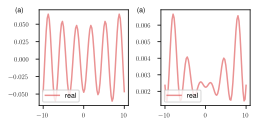

In [306]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams.update({
    "text.usetex": True,  # LaTeX 사용
    "font.family": "Helvetica",
    "font.size": 7,  # 논문에 맞는 폰트 크기 설정 (보통 8~10pt)
})

# LaTeX 글꼴과 문서 일관성을 위한 preamble
plt.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}  % 수학 표현 개선
\usepackage{amssymb}  % 수학 심볼 추가
"""

cm    = 1.0/2.54
width = 18/2*cm 
height = 18/4*cm 
plt.figure(figsize=(width,height),dpi=600)

marker_style_ref = dict(marker='',linestyle='dashed',linewidth=1.0, color='black')
marker_style_1  = dict(marker='', linestyle='-', color='tab:red', alpha=0.5,  fillstyle='none')
marker_style_2  = dict(marker='', linestyle='-', color='blue', alpha=0.9,  fillstyle='full')


axes = []
ax = plt.subplot2grid((1,2),(0,0))
axes.append(ax)
ax = plt.subplot2grid((1,2),(0,1))
axes.append(ax)

# (a) energies

axis = axes[0]

#y_min    =   -7.6
#y_max    =   0.0
##
#x_min    =  1
#x_max    =  13

#axis.set_xlim(x_min,x_max)
#axis.set_ylim(y_min,y_max)
# setup labels
#axes[0].text(-0.25,0.98,'(a)',transform=axes[0].transAxes)
axis.text(-0.27,0.975,r'(a)',transform=axis.transAxes)
#axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
#axis.set_xlabel(r'\# of sites')
#axis.set_ylabel(r'$E_g/J$')
## setup tics
#axis.tick_params(axis='x', which='both', direction='in')
#axis.tick_params(axis='y', which='both', direction='in')
#axis.xaxis.set_major_locator(ticker.MultipleLocator(2))
##axis.xaxis.set_major_formatter('{:}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(1))
#
#axis.yaxis.set_major_locator(ticker.MultipleLocator(2))
##axis.yaxis.set_major_formatter('{x:0.1f}')
#axis.yaxis.set_minor_locator(ticker.MultipleLocator(1))

# plot
axis.plot(times, o_error_real, label='real', **marker_style_1)
#axis.plot(times, o_error_imag, label='imag', **marker_style_2)

axis.legend(loc='lower left')

axis = axes[1]

#y_min    =   -7.6
#y_max    =   0.0
##
#x_min    =  1
#x_max    =  13

#axis.set_xlim(x_min,x_max)
#axis.set_ylim(y_min,y_max)
# setup labels
#axes[0].text(-0.25,0.98,'(a)',transform=axes[0].transAxes)
axis.text(-0.27,0.975,r'(a)',transform=axis.transAxes)
#axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
#axis.set_xlabel(r'\# of sites')
#axis.set_ylabel(r'$E_g/J$')
## setup tics
#axis.tick_params(axis='x', which='both', direction='in')
#axis.tick_params(axis='y', which='both', direction='in')
#axis.xaxis.set_major_locator(ticker.MultipleLocator(2))
##axis.xaxis.set_major_formatter('{:}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(1))
#
#axis.yaxis.set_major_locator(ticker.MultipleLocator(2))
##axis.yaxis.set_major_formatter('{x:0.1f}')
#axis.yaxis.set_minor_locator(ticker.MultipleLocator(1))

# plot
axis.plot(times, p_error_real, label='real', **marker_style_1)
#axis.plot(times, p_error_imag, label='imag', **marker_style_2)
axis.legend(loc='lower left')


#
plt.tight_layout()
#

In [302]:
print(2*np.pi / (eigen_energies_exact[1,1]-eigen_energies_exact[1,0]))

3.3300815526487355
